[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_01_regression.ipynb)

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
# We import:
# - numpy for math and arrays
# - matplotlib for plots
# - sklearn for linear regression and MSE
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# This seed makes random numbers repeatable.
# If someone runs this notebook again, they will get the same fake data.
rng = np.random.default_rng(42)

# =============================================================================
# PART A — Create beginner-friendly toy data
# =============================================================================
# Goal: make a simple dataset where y depends on x in an almost-linear way.
# We start from a "true" line, then add random noise to mimic measurement errors.

N = 50                                   # how many data points we create
x_true = rng.uniform(1, 10, size=N)     # input values x (random between 1 and 10)
noise   = rng.normal(0, 1.5, size=N)    # random noise with standard deviation 1.5

# Hidden (ground-truth) line used to generate data.
TRUE_SLOPE     = -2.5
TRUE_INTERCEPT = 30.0

# Observed y values = true line + noise.
y_true = TRUE_SLOPE * x_true + TRUE_INTERCEPT + noise

print("=" * 55)
print("  STEP 1 — Linear Regression")
print("=" * 55)
print(f"\nGenerated {N} fake observations.")
print(f"True model:  y = {TRUE_SLOPE} * x + {TRUE_INTERCEPT}  + noise")
print(f"Noise std :  σ = 1.5\n")

  STEP 1 — Linear Regression

Generated 50 fake observations.
True model:  y = -2.5 * x + 30.0  + noise
Noise std :  σ = 1.5



In [2]:
# =============================================================================
# PART B — Understand the loss function
# =============================================================================
# For regression, a very common loss is Mean Squared Error (MSE):
#
#   L(theta) = (1/N) * sum((y_i - y_hat_i)^2)
#
# y_i      = true value
# y_hat_i  = predicted value
#
# Bigger errors are penalized more because of the square.
# Smaller MSE means a better fit.

def mse_loss(slope, intercept, x, y):
    """Return MSE for a line defined by slope and intercept."""
    y_pred = slope * x + intercept          # predicted y values from the line
    residuals = y - y_pred                  # difference between true and predicted values
    return np.mean(residuals ** 2)          # average squared residual

# Compare two parameter choices:
# 1) an obviously bad guess
# 2) the true parameters used to generate data
loss_bad_guess  = mse_loss(-1.0, 20.0, x_true, y_true)
loss_true_theta = mse_loss(TRUE_SLOPE, TRUE_INTERCEPT, x_true, y_true)

print(f"Loss with bad  θ  (slope=-1.0, int=20.0) : L = {loss_bad_guess:.2f}")
print(f"Loss with true θ  (slope=-2.5, int=30.0) : L = {loss_true_theta:.2f}")
print("→ Smaller loss = better model!\n")

Loss with bad  θ  (slope=-1.0, int=20.0) : L = 16.03
Loss with true θ  (slope=-2.5, int=30.0) : L = 1.36
→ Smaller loss = better model!



`sklearn` (scikit-learn) is a widely used Python library for machine learning. It provides easy-to-use tools for tasks like regression, classification, and clustering, and is built on top of `numpy` and `scipy`. For more details and advanced usage, you can refer to the [scikit-learn documentation](https://scikit-learn.org/).  

For more information on linear regression in scikit-learn, see the [official documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [ ]:
# =============================================================================
# PART C — Let sklearn fit the best line
# =============================================================================
# LinearRegression finds slope/intercept that minimize squared error.
# For this model, sklearn can solve it directly (no iterative training loop needed).

# sklearn expects X as 2D: (number_of_samples, number_of_features)
# Here we have one feature, so shape should be (N, 1).
X = x_true.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y_true)      # fitting = finding the best slope/intercept

learned_slope     = model.coef_[0]
learned_intercept = model.intercept_

print(f"sklearn found:")
print(f"  Learned slope     = {learned_slope:.4f}  (true: {TRUE_SLOPE})")
print(f"  Learned intercept = {learned_intercept:.4f}  (true: {TRUE_INTERCEPT})")
print(f"  Residual L (MSE)  = {mean_squared_error(y_true, model.predict(X)):.4f}\n")

sklearn found:
  Learned slope     = -2.4799  (true: -2.5)
  Learned intercept = 29.6329  (true: 30.0)
  Residual L (MSE)  = 1.2903



### What this code is doing

This cell visualizes linear regression from two complementary angles:

1. **Prediction view (data space):** it draws the learned regression line on top of the observed data and shows **residuals** (vertical red segments).
2. **Optimization view (parameter space):** it computes the MSE loss for many $(\text{slope}, \text{intercept})$ pairs and plots a contour map of the loss landscape.

Together, these views connect the model equation to the objective function: minimizing residual errors in data space corresponds to finding the minimum of $L(\theta)$ in parameter space.

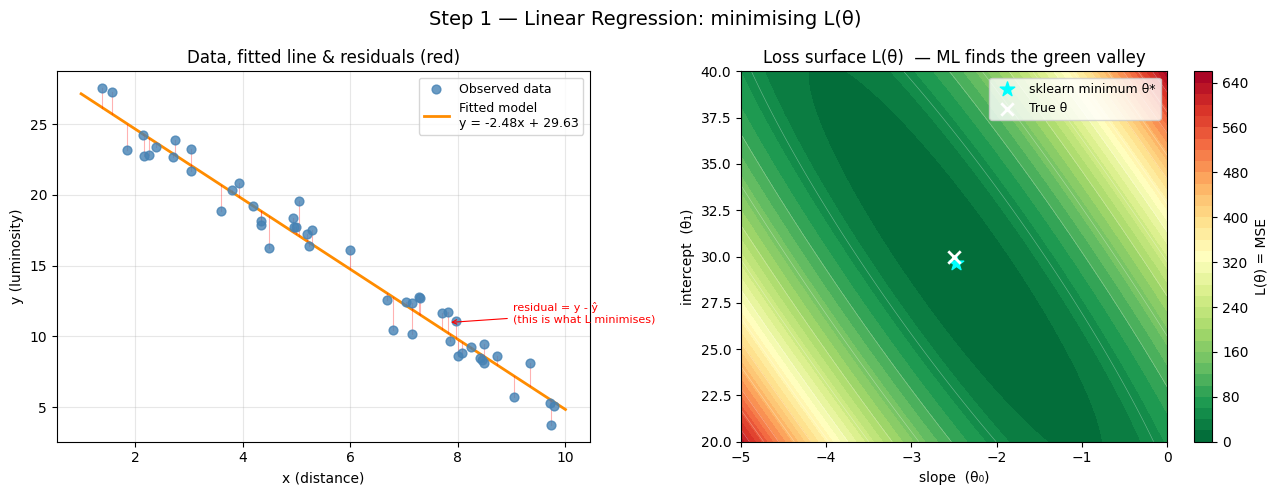

Plot saved to step1_regression.png


In [4]:
# =============================================================================
# PART D — Visualize predictions and loss landscape
# =============================================================================

# Build smooth x values for drawing the fitted line.
x_line = np.linspace(1, 10, 200).reshape(-1, 1)
y_line = model.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Step 1 — Linear Regression: minimising L(θ)", fontsize=14)

# ── Left plot: data points, fitted line, and residuals ───────────────────────
ax = axes[0]
ax.scatter(x_true, y_true, color="steelblue", zorder=3,
           label="Observed data", s=40, alpha=0.8)
ax.plot(x_line, y_line, color="darkorange", linewidth=2,
        label=f"Fitted model\ny = {learned_slope:.2f}x + {learned_intercept:.2f}")

# Residual = vertical gap between data point and model prediction at same x.
y_pred_at_data = model.predict(X)
for xi, yi, yp in zip(x_true, y_true, y_pred_at_data):
    ax.plot([xi, xi], [yi, yp], color="red", alpha=0.3, linewidth=0.8)

ax.set_xlabel("x (distance)")
ax.set_ylabel("y (luminosity)")
ax.set_title("Data, fitted line & residuals (red)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Annotate one residual so beginners can see exactly what it means.
idx = 20
xi, yi, yp = x_true[idx], y_true[idx], y_pred_at_data[idx]
ax.annotate("residual = y - ŷ\n(this is what L minimises)",
            xy=(xi, (yi + yp)/2),
            xytext=(xi + 1.2, (yi + yp)/2),
            fontsize=8, color="red",
            arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

# ── Right plot: loss values for many slope/intercept pairs ───────────────────
ax2 = axes[1]

slopes      = np.linspace(-5, 0, 120)
intercepts  = np.linspace(20, 40, 120)
S, I = np.meshgrid(slopes, intercepts)

# Evaluate MSE at each point in parameter space.
L = np.array([[mse_loss(s, ic, x_true, y_true)
               for s in slopes]
              for ic in intercepts])

# Contour map: lower values (better fits) form the "valley".
cf = ax2.contourf(S, I, L, levels=40, cmap="RdYlGn_r")
plt.colorbar(cf, ax=ax2, label="L(θ) = MSE")
ax2.contour(S, I, L, levels=15, colors="white", linewidths=0.4, alpha=0.4)

# Mark sklearn solution and true parameters.
ax2.scatter(learned_slope, learned_intercept,
            color="cyan", s=120, zorder=5, label="sklearn minimum θ*", marker="*")
ax2.scatter(TRUE_SLOPE, TRUE_INTERCEPT,
            color="white", s=80, zorder=5, label="True θ", marker="x", linewidths=2)

ax2.set_xlabel("slope  (θ₀)")
ax2.set_ylabel("intercept  (θ₁)")
ax2.set_title("Loss surface L(θ)  — ML finds the green valley")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("./step1_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to step1_regression.png")

### Detailed plot explanation

#### Left plot: Data, fitted line, and residuals

- `x_line` creates 200 evenly spaced x-values so the fitted line appears smooth.
- `y_line = model.predict(x_line)` computes predictions from the trained model.
- Blue points are the observed samples `(x_true, y_true)`.
- Orange line is the fitted linear model:
  
  $$
  \hat{y} = \theta_0 x + \theta_1
  $$

- For each training sample, the red vertical segment is the **residual**:
  
  $$
  r_i = y_i - \hat{y}_i
  $$

- The annotation highlights one residual to show that the loss is built from these vertical errors.

Interpretation:
- Shorter red segments mean smaller prediction errors.
- A good fit places the line so the residuals are generally small and balanced around the line.

#### Right plot: Loss surface $L(\theta)$

- A grid of candidate parameters is built:
  - `slopes` (x-axis in this plot)
  - `intercepts` (y-axis in this plot)
- For each parameter pair `(s, ic)`, the code computes:
  
  $$
  L(\theta) = \text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - (sx_i + ic))^2
  $$

- `contourf` colors the loss values (green = low loss, red = high loss).
- White contour lines show equal-loss levels, making the valley shape easier to read.
- Cyan star marks the parameter pair found by `sklearn` (the estimated minimum).
- White `x` marks the ground-truth parameters used to generate the synthetic data.

Interpretation:
- The “valley” corresponds to parameter combinations that fit the data well.
- Moving away from the valley increases loss quickly.
- The learned solution near the true parameters indicates successful recovery despite noise.

### Key intuition

- **Left plot:** “How wrong are predictions at each data point?”
- **Right plot:** “Where in parameter space is that total error minimized?”

These are two views of the same learning process.

In [5]:
# =============================================================================
# PART E — Print key takeaways
# =============================================================================
print("\n" + "=" * 55)
print("  KEY TAKEAWAYS")
print("=" * 55)
print("""
1. A MODEL  f(x; θ)  maps inputs x to predicted outputs.

2. A LOSS FUNCTION  L(θ)  measures how wrong the model is.
   For regression: L = MSE = mean( (y - ŷ)^2 )

3. ML = find θ* = argmin L(θ)
   This is always the goal, regardless of model complexity.

4. The LOSS SURFACE (right plot) shows L as a function of θ.
   The optimizer's job is to move toward the minimum.

5. For linear regression, the minimum has a closed-form solution.
   For deep neural networks, we usually use gradient descent.

PHYSICS ANALOGY:
  This is similar to fitting a model by minimizing chi^2.
  Under Gaussian noise assumptions, these ideas are closely related.
""")


  KEY TAKEAWAYS

1. A MODEL  f(x; θ)  maps inputs x to predicted outputs.

2. A LOSS FUNCTION  L(θ)  measures how wrong the model is.
   For regression: L = MSE = mean( (y - ŷ)^2 )

3. ML = find θ* = argmin L(θ)
   This is always the goal, regardless of model complexity.

4. The LOSS SURFACE (right plot) shows L as a function of θ.
   The optimizer's job is to move toward the minimum.

5. For linear regression, the minimum has a closed-form solution.
   For deep neural networks, we usually use gradient descent.

PHYSICS ANALOGY:
  This is similar to fitting a model by minimizing chi^2.
  Under Gaussian noise assumptions, these ideas are closely related.

